## First cell — always set the project root

In [2]:
import os
import sys

# Add project root to path so we can import src modules
sys.path.insert(0, os.path.abspath(".."))

# Verify
import src
print("Project root added to path ✓")
print(f"Working from: {os.path.abspath('..')}")

Project root added to path ✓
Working from: /home/mrityunjay/churn-production


## Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Our own modules
from src.data.loader import load_raw_data, basic_clean
from src.data.validator import validate
from src.features.engineer import create_domain_features

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

print("Imports successful ✓")


Imports successful ✓


# Load raw data (BEFORE cleaning)

In [8]:
df_raw = load_raw_data("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Raw data loaded ✓")
print(f"Data shape: {df_raw.shape}")
print("Sample data:")
display(df_raw.head())

2026-03-15T23:32:51 | INFO     | src.data.loader:16 | Loading data from: ../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv
2026-03-15T23:32:51 | INFO     | src.data.loader:19 | Shape: (7043, 21)
2026-03-15T23:32:51 | INFO     | src.data.loader:20 | Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Raw data loaded ✓
Data shape: (7043, 21)
Sample data:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Null check

In [10]:
nulls = df_raw.isnull().sum()
print("Null values in each column:")
print(nulls[nulls > 0])
print("---------------------------------------------------")

# check total charges specifically- this is the tricky one 

print("TotalCharges dtype:", df_raw["TotalCharges"].dtype)
print("TotalCharges sample values:", df_raw["TotalCharges"].sample(5).values)
print("---------------------------------------------------")

mask = df_raw["TotalCharges"].str.strip() == ""
print(f"Whitespace-only TotalCharges rows: {mask.sum()} rows")
print(df_raw[mask][["customerID","tenure","MonthlyCharges", "TotalCharges"]])

Null values in each column:
Series([], dtype: int64)
---------------------------------------------------
TotalCharges dtype: object
TotalCharges sample values: ['206.15' '2976.95' '265.8' '840.1' '163.6']
---------------------------------------------------
Whitespace-only TotalCharges rows: 11 rows
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             


## Clean data and compare

In [11]:
df = basic_clean(df_raw)
print("Data cleaned ✓")
print(f"TotalCharges dtype after cleaning: {df['TotalCharges'].dtype}")
print(f"nulls remaining after cleaning: {df.isnull().sum().sum()}")
print(f"\n Same 11 rows after fix")
inx = [488, 753, 936, 1082, 1340, 3331,3826, 4380, 5218, 6670, 6754]
print(df.loc[inx, ["customerID","tenure","MonthlyCharges", "TotalCharges"]])

2026-03-15T23:42:40 | INFO     | src.data.loader:34 | Fixed 11 TotalCharges nulls
2026-03-15T23:42:40 | INFO     | src.data.loader:41 | Churn rate: 26.54%  |  Class counts: {0: 5174, 1: 1869}
Data cleaned ✓
TotalCharges dtype after cleaning: float64
nulls remaining after cleaning: 0

 Same 11 rows after fix
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55         52.55
753   3115-CZMZD       0           20.25         20.25
936   5709-LVOEQ       0           80.85         80.85
1082  4367-NUYAO       0           25.75         25.75
1340  1371-DWPAZ       0           56.05         56.05
3331  7644-OMVMY       0           19.85         19.85
3826  3213-VVOLG       0           25.35         25.35
4380  2520-SGTTA       0           20.00         20.00
5218  2923-ARZLG       0           19.70         19.70
6670  4075-WKNIU       0           73.35         73.35
6754  2775-SEFEE       0           61.90         61.90


## Target distribution (Class imbalance)

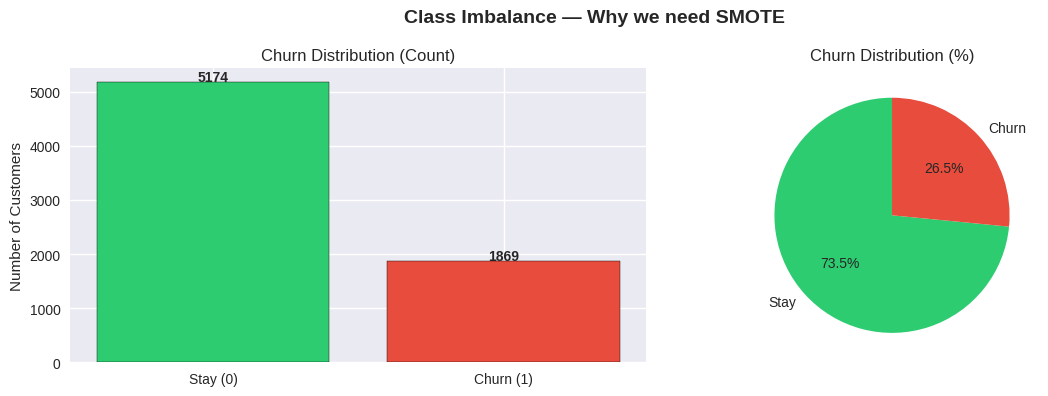

Churn rate: 26.54%
Imbalance ratio: 1:2


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
churn_counts = df["Churn"].value_counts()
axes[0].bar(["Stay (0)", "Churn (1)"], churn_counts.values, 
            color=["#2ecc71", "#e74c3c"], edgecolor="black")
axes[0].set_title("Churn Distribution (Count)")
axes[0].set_ylabel("Number of Customers")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

# Percentage plot
churn_pct = df["Churn"].value_counts(normalize=True) * 100
axes[1].pie(churn_pct.values, labels=["Stay", "Churn"], 
            colors=["#2ecc71", "#e74c3c"],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Churn Distribution (%)")

plt.suptitle("Class Imbalance — Why we need SMOTE", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../artifacts/eda_churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Churn rate: {df['Churn'].mean():.2%}")
print(f"Imbalance ratio: 1:{df['Churn'].value_counts()[0] // df['Churn'].value_counts()[1]}")

##  Churn by Contract Type

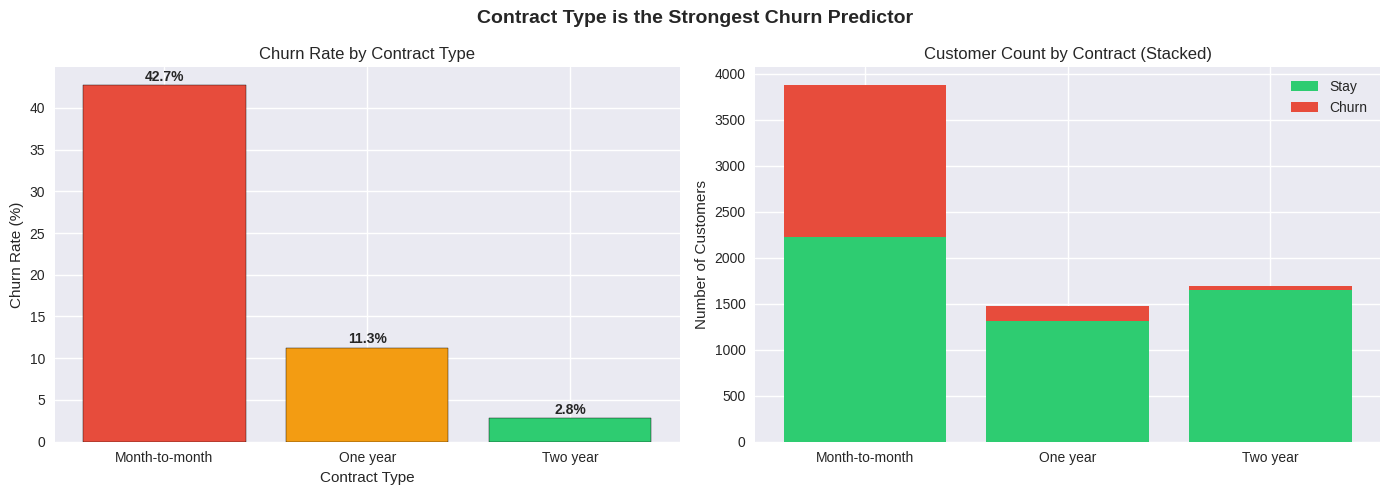

                churned  total  churn_rate_pct
Contract                                      
Month-to-month     1655   3875           42.71
One year            166   1473           11.27
Two year             48   1695            2.83


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count by contract
contract_churn = df.groupby("Contract")["Churn"].agg(["sum", "count", "mean"])
contract_churn.columns = ["churned", "total", "churn_rate"]
contract_churn["churn_rate_pct"] = contract_churn["churn_rate"] * 100

# Bar plot - churn rate
axes[0].bar(contract_churn.index, contract_churn["churn_rate_pct"],
            color=["#e74c3c", "#f39c12", "#2ecc71"], edgecolor="black")
axes[0].set_title("Churn Rate by Contract Type")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_xlabel("Contract Type")
for i, (idx, row) in enumerate(contract_churn.iterrows()):
    axes[0].text(i, row["churn_rate_pct"] + 0.5, 
                 f"{row['churn_rate_pct']:.1f}%", ha="center", fontweight="bold")

# Stacked bar - absolute numbers
stayed = contract_churn["total"] - contract_churn["churned"]
axes[1].bar(contract_churn.index, stayed, label="Stay", color="#2ecc71")
axes[1].bar(contract_churn.index, contract_churn["churned"], 
            bottom=stayed, label="Churn", color="#e74c3c")
axes[1].set_title("Customer Count by Contract (Stacked)")
axes[1].set_ylabel("Number of Customers")
axes[1].legend()

plt.suptitle("Contract Type is the Strongest Churn Predictor", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../artifacts/eda_contract_churn.png", dpi=150, bbox_inches="tight")
plt.show()

print(contract_churn[["churned", "total", "churn_rate_pct"]])

## Churn by Tenure

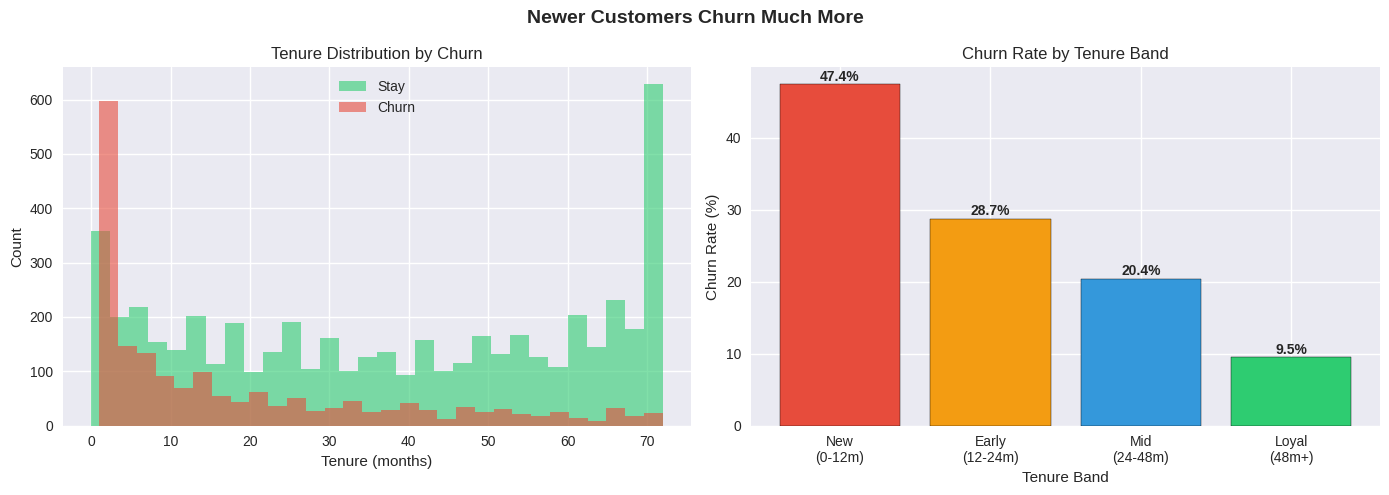


Churn rate by tenure band:
tenure_band
New\n(0-12m)      47.40
Early\n(12-24m)   28.70
Mid\n(24-48m)     20.40
Loyal\n(48m+)      9.50
Name: Churn, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure distribution by churn
df[df["Churn"] == 0]["tenure"].hist(bins=30, alpha=0.6, 
                                     color="#2ecc71", label="Stay", ax=axes[0])
df[df["Churn"] == 1]["tenure"].hist(bins=30, alpha=0.6, 
                                     color="#e74c3c", label="Churn", ax=axes[0])
axes[0].set_title("Tenure Distribution by Churn")
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Churn rate by tenure band
df["tenure_band"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["New\n(0-12m)", "Early\n(12-24m)", "Mid\n(24-48m)", "Loyal\n(48m+)"],
    include_lowest=True,
)
tenure_churn = df.groupby("tenure_band", observed=True)["Churn"].mean() * 100
axes[1].bar(tenure_churn.index, tenure_churn.values,
            color=["#e74c3c", "#f39c12", "#3498db", "#2ecc71"], edgecolor="black")
axes[1].set_title("Churn Rate by Tenure Band")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].set_xlabel("Tenure Band")
for i, v in enumerate(tenure_churn.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Newer Customers Churn Much More", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../artifacts/eda_tenure_churn.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nChurn rate by tenure band:")
print(tenure_churn.round(1))

## Monthly Charges vs Churn

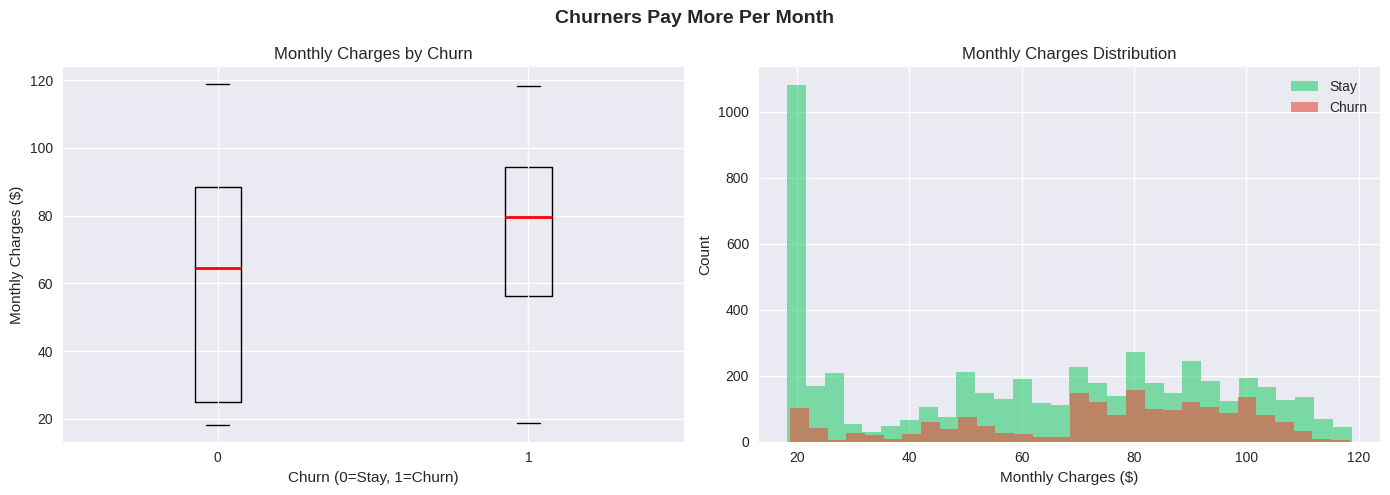

Avg MonthlyCharges — Stay:  $61.27
Avg MonthlyCharges — Churn: $74.44


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
df.boxplot(column="MonthlyCharges", by="Churn", ax=axes[0],
           boxprops=dict(color="black"),
           medianprops=dict(color="red", linewidth=2))
axes[0].set_title("Monthly Charges by Churn")
axes[0].set_xlabel("Churn (0=Stay, 1=Churn)")
axes[0].set_ylabel("Monthly Charges ($)")

# Distribution overlay
df[df["Churn"] == 0]["MonthlyCharges"].hist(bins=30, alpha=0.6,
                                             color="#2ecc71", label="Stay", ax=axes[1])
df[df["Churn"] == 1]["MonthlyCharges"].hist(bins=30, alpha=0.6,
                                             color="#e74c3c", label="Churn", ax=axes[1])
axes[1].set_title("Monthly Charges Distribution")
axes[1].set_xlabel("Monthly Charges ($)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.suptitle("Churners Pay More Per Month", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../artifacts/eda_charges_churn.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Avg MonthlyCharges — Stay:  ${df[df['Churn']==0]['MonthlyCharges'].mean():.2f}")
print(f"Avg MonthlyCharges — Churn: ${df[df['Churn']==1]['MonthlyCharges'].mean():.2f}")

##  Correlation Heatmap

2026-03-15T23:52:34 | INFO     | src.features.engineer:14 | Created: charges_per_tenure
2026-03-15T23:52:34 | INFO     | src.features.engineer:25 | Created: tenure_band
2026-03-15T23:52:34 | INFO     | src.features.engineer:34 | Created: service_count
2026-03-15T23:52:34 | INFO     | src.features.engineer:39 | Created: is_month_to_month
2026-03-15T23:52:34 | INFO     | src.features.engineer:44 | Created: is_electronic_check
2026-03-15T23:52:34 | INFO     | src.features.engineer:51 | Created: no_support_services
2026-03-15T23:52:34 | INFO     | src.features.engineer:53 | Feature engineering complete. Shape: (7043, 27)


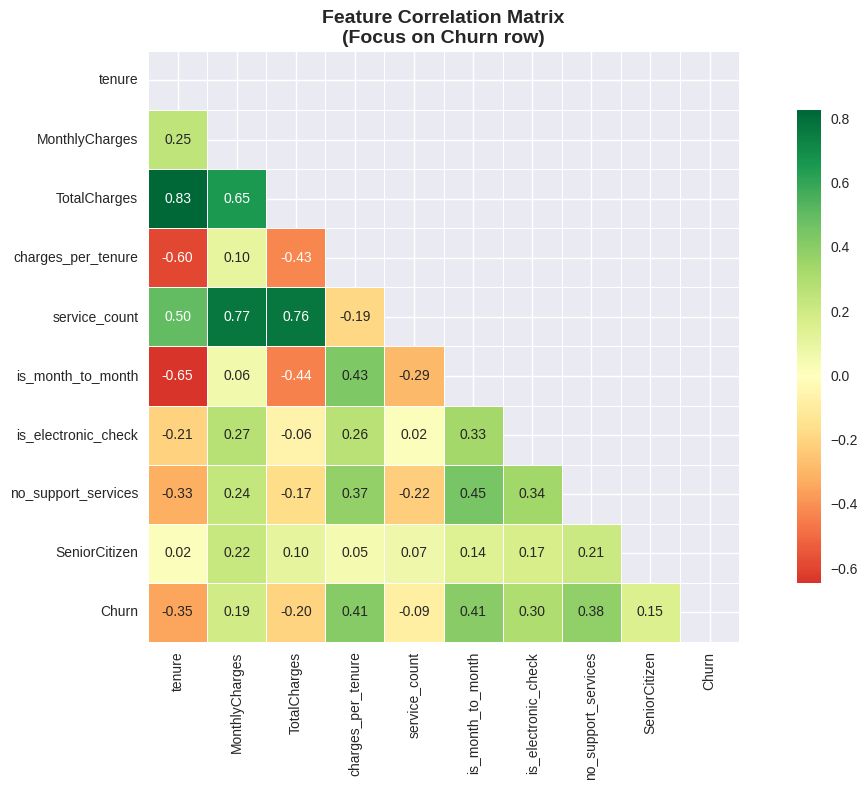


Correlation with Churn (sorted):
charges_per_tenure     0.41
is_month_to_month      0.41
no_support_services    0.38
is_electronic_check    0.30
MonthlyCharges         0.19
SeniorCitizen          0.15
service_count         -0.09
TotalCharges          -0.20
tenure                -0.35
Name: Churn, dtype: float64


In [16]:
# Add engineered features for correlation analysis
df_eng = create_domain_features(df.drop(columns=["tenure_band"], errors="ignore"))

# Select only numeric columns
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges",
                "charges_per_tenure", "service_count",
                "is_month_to_month", "is_electronic_check",
                "no_support_services", "SeniorCitizen", "Churn"]

corr_matrix = df_eng[numeric_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Feature Correlation Matrix\n(Focus on Churn row)", 
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../artifacts/eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCorrelation with Churn (sorted):")
print(corr_matrix["Churn"].drop("Churn").sort_values(ascending=False).round(3))

##  Final EDA Summary

In [17]:
print("=" * 55)
print("       EDA FINDINGS SUMMARY")
print("=" * 55)

print(f"""
DATASET:
  Rows:          {df.shape[0]:,}
  Columns:       {df_raw.shape[1]}
  Churn rate:    {df['Churn'].mean():.2%} (imbalanced → needs SMOTE)
  Null values:   11 (TotalCharges whitespace → fixed)

TOP CHURN DRIVERS:
  1. Contract type
     Month-to-month → {df[df['Contract']=='Month-to-month']['Churn'].mean():.1%} churn
     Two year       → {df[df['Contract']=='Two year']['Churn'].mean():.1%} churn

  2. Tenure
     0-12 months    → {df[df['tenure']<=12]['Churn'].mean():.1%} churn
     48+ months     → {df[df['tenure']>=48]['Churn'].mean():.1%} churn

  3. Internet Service
     Fiber optic    → {df[df['InternetService']=='Fiber optic']['Churn'].mean():.1%} churn
     No internet    → {df[df['InternetService']=='No']['Churn'].mean():.1%} churn

  4. Payment Method
     Electronic check → {df[df['PaymentMethod']=='Electronic check']['Churn'].mean():.1%} churn
     Auto payment     → {df[df['PaymentMethod']=='Bank transfer (automatic)']['Churn'].mean():.1%} churn

FEATURE ENGINEERING JUSTIFIED:
  ✓ charges_per_tenure   — high charges + low tenure = risk
  ✓ tenure_band          — lifecycle stage matters
  ✓ service_count        — engagement proxy
  ✓ is_month_to_month    — strongest single predictor
  ✓ is_electronic_check  — payment friction signal
  ✓ no_support_services  — unsupported customers leave
""")
print("=" * 55)

       EDA FINDINGS SUMMARY

DATASET:
  Rows:          7,043
  Columns:       21
  Churn rate:    26.54% (imbalanced → needs SMOTE)
  Null values:   11 (TotalCharges whitespace → fixed)

TOP CHURN DRIVERS:
  1. Contract type
     Month-to-month → 42.7% churn
     Two year       → 2.8% churn

  2. Tenure
     0-12 months    → 47.4% churn
     48+ months     → 9.6% churn

  3. Internet Service
     Fiber optic    → 41.9% churn
     No internet    → 7.4% churn

  4. Payment Method
     Electronic check → 45.3% churn
     Auto payment     → 16.7% churn

FEATURE ENGINEERING JUSTIFIED:
  ✓ charges_per_tenure   — high charges + low tenure = risk
  ✓ tenure_band          — lifecycle stage matters
  ✓ service_count        — engagement proxy
  ✓ is_month_to_month    — strongest single predictor
  ✓ is_electronic_check  — payment friction signal
  ✓ no_support_services  — unsupported customers leave

